<a href="https://colab.research.google.com/github/sjhallo07/Quantum_Relativistic_Engine/blob/main/bridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sección nueva

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.5}
   -> Updated lambda_thr to 2.5
📚 Bridge advice: {'lambda_thr': 2.

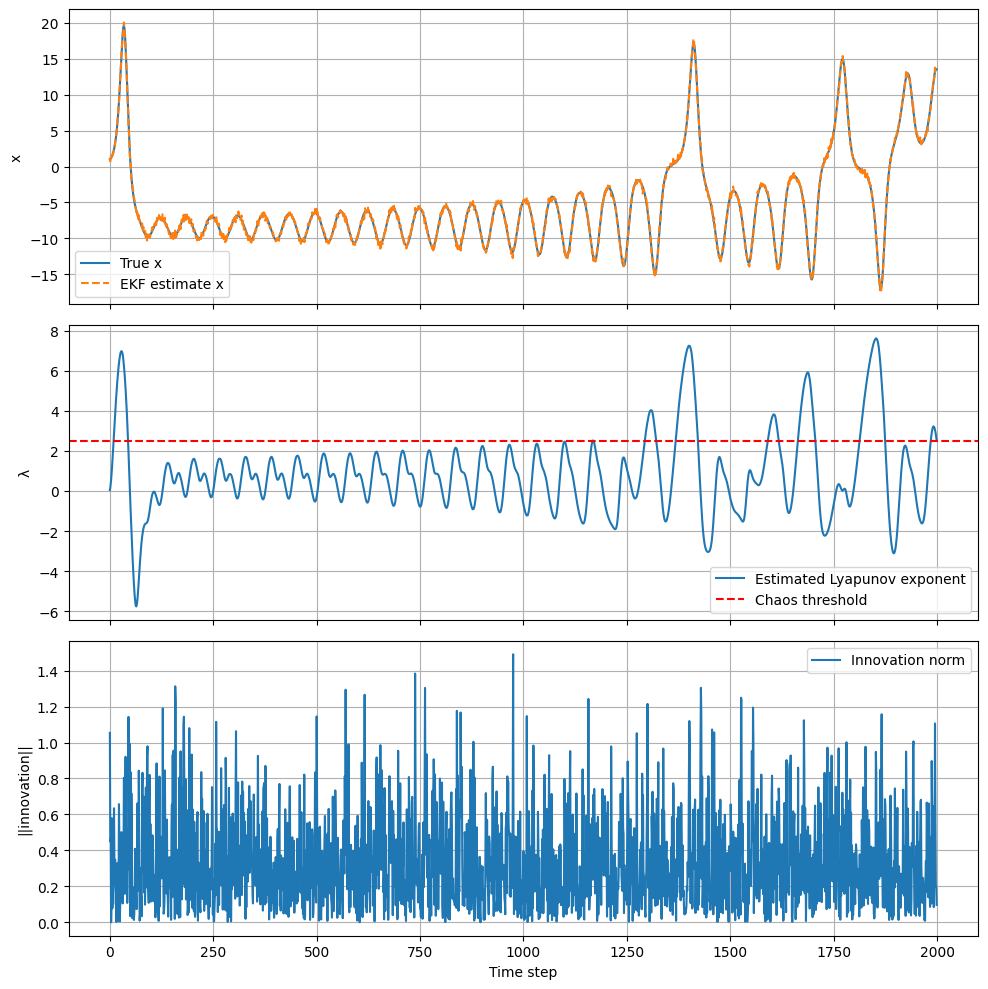

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from sentence_transformers import SentenceTransformer, util
import re
import torch

# ------------------------------------------------------------
# 1. Lorenz system and Jacobian (same as before)
# ------------------------------------------------------------
def lorenz_deriv(state, t, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x*(rho - z) - y
    dz = x*y - beta*z
    return np.array([dx, dy, dz])

def lorenz_step(state, dt):
    t = np.array([0, dt])
    sol = odeint(lorenz_deriv, state, t)
    return sol[1]

def lorenz_jacobian(state):
    x, y, z = state
    sigma, rho, beta = 10.0, 28.0, 8.0/3.0
    J = np.array([
        [-sigma, sigma, 0],
        [rho - z, -1, -x],
        [y, x, -beta]
    ])
    return J

# ------------------------------------------------------------
# 2. EKF predict and update
# ------------------------------------------------------------
def ekf_predict(x, P, dt, Q):
    x_pred = lorenz_step(x, dt)
    F = np.eye(3) + lorenz_jacobian(x) * dt
    P_pred = F @ P @ F.T + Q
    return x_pred, P_pred

def ekf_update(x_pred, P_pred, z, H, R):
    y = z - H @ x_pred
    S = H @ P_pred @ H.T + R
    K = P_pred @ H.T @ np.linalg.inv(S)
    x_upd = x_pred + K @ y
    P_upd = (np.eye(3) - K @ H) @ P_pred
    return x_upd, P_upd, y, K

# ------------------------------------------------------------
# 3. Lyapunov estimation
# ------------------------------------------------------------
def update_lyapunov(delta, F, dt, lambda_avg, alpha=0.95):
    delta_new = F @ delta
    norm_old = np.linalg.norm(delta)
    norm_new = np.linalg.norm(delta_new)
    if norm_old < 1e-12:
        lambda_inst = 0.0
    else:
        lambda_inst = (1.0/dt) * np.log(norm_new / norm_old)
    lambda_avg = alpha * lambda_avg + (1 - alpha) * lambda_inst
    if norm_new > 1e-12:
        delta_new = delta_new / norm_new
    return delta_new, lambda_avg, lambda_inst

# ------------------------------------------------------------
# 4. Safe memory (soft recovery)
# ------------------------------------------------------------
class SafeMemory:
    def __init__(self, safe_state, max_size=30, max_age_steps=100):
        self.safe_state = safe_state.copy()
        self.buffer = []
        self.max_size = max_size
        self.max_age = max_age_steps

    def add(self, state, innov, step):
        if innov < 0.5:
            self.buffer.append((state.copy(), innov, step))
            self.buffer = [(s, i, st) for (s, i, st) in self.buffer if step - st < self.max_age]
            if len(self.buffer) > self.max_size:
                self.buffer.pop(0)

    def recover(self, current_state, current_innov, chaos_detected, innov_high_thr=2.0, blend_factor=0.2):
        if chaos_detected and current_innov > innov_high_thr:
            if self.buffer:
                best_state, best_innov, _ = max(self.buffer, key=lambda x: x[2])
                new_state = (1 - blend_factor) * current_state + blend_factor * best_state
                print(f"🔄 Blend with recent good state (innov={best_innov:.3f})")
            else:
                new_state = (1 - blend_factor) * current_state + blend_factor * self.safe_state
                print(f"🔄 Blend with safe state (no recent good)")
            return new_state
        return current_state

# ------------------------------------------------------------
# 5. Semantic Bridge: retrieves physics knowledge and extracts parameters
# ------------------------------------------------------------
class PhysicsBridge:
    def __init__(self, model_name="intfloat/multilingual-e5-large", corpus=None):
        self.model = SentenceTransformer(model_name)
        if corpus is None:
            # Default physics corpus (can be extended) - now using 'better_corpus'
            enriched_corpus = [
    # Umbral de Lyapunov
    "For the Lorenz system, the maximum Lyapunov exponent is about 0.9. Set Lyapunov threshold to 1.2 to avoid false chaos triggers.",
    "If the estimated Lyapunov exponent exceeds 1.5 for several consecutive steps, increase the threshold temporarily to 1.8 to prevent over‑sensitivity.",
    "When the system is highly chaotic (Lyapunov > 2.0), raise the Lyapunov threshold to 2.5 and increase beta_meta to 0.8 for faster adaptation.",

    # Meta‑aprendizaje (beta_meta)
    "For slow adaptation of process noise, set beta_meta = 0.5. This avoids oscillations.",
    "If chaos persists and innovation remains above 3.0, increase beta_meta to 0.8 to speed up the increase of Q.",
    "After a successful recovery, reset beta_meta to 0.5 to return to slow adaptation.",

    # Blending factor (recuperación suave)
    "When chaos is detected and innovation exceeds 2.0, use a blend factor of 0.2 to softly pull the state toward a safe point.",
    "If the innovation norm stays above 5.0 for more than 5 steps, increase the blend factor to 0.4 to correct more aggressively.",
    "After a recovery, set blend factor back to 0.2 to maintain stability.",

    # Ruido de medición R
    "Measurement noise R should be 0.1 for clean x measurements. If tracking is poor, reduce R to 0.05 to trust measurements more.",
    "If innovation is consistently high, consider reducing R to 0.02 to make the filter rely more on observations.",
    "When the filter is stable and innovation low, increase R to 0.2 to avoid over‑fitting to noisy measurements.",

    # Covarianza del proceso Q_base
    "The base process noise covariance Q_base should be diag([0.5, 0.5, 0.5]) for normal operation.",
    "In extreme chaos, increase Q_base to diag([1.0, 1.0, 1.0]) to let the filter trust measurements more.",
    "If the system becomes too jumpy, reduce Q_base to diag([0.1, 0.1, 0.1]) for smoother estimates.",
]
            self.corpus = enriched_corpus
        else:
            self.corpus = corpus
        # Encode corpus once
        self.passages = [f"passage: {chunk}" for chunk in self.corpus]
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.corpus_embeddings = self.model.encode(self.passages, convert_to_tensor=True, device=self.device)

    def query(self, natural_language_query, top_k=1):
        """Retrieve the most relevant passage and extract numerical parameters."""
        query_text = f"query: {natural_language_query}"
        query_embedding = self.model.encode(query_text, convert_to_tensor=True, device=self.device)
        hits = util.semantic_search(query_embedding, self.corpus_embeddings, top_k=top_k)[0]
        best_idx = hits[0]['corpus_id']
        retrieved_text = self.corpus[best_idx]
        # Parse parameters (simple regex extraction)
        params = self._extract_parameters(retrieved_text)
        return params, retrieved_text

    def _extract_parameters(self, text):
        params = {}
        # lambda_thr
        match = re.search(r'threshold\s*(?:to|=|:)?\s*([\d.]+)', text, re.I)
        if match: params['lambda_thr'] = float(match.group(1))
        # beta_meta
        match = re.search(r'beta_meta\s*(?:=|\s+)?([\d.]+)', text, re.I)
        if match: params['beta_meta'] = float(match.group(1))
        # blend_factor
        match = re.search(r'blend[_ ]?factor\s*(?:=|\s+)?([\d.]+)', text, re.I)
        if match: params['blend_factor'] = float(match.group(1))
        # R (measurement noise)
        match = re.search(r'\bR\s*(?:=|\s+)?([\d.]+)', text, re.I)
        if match: params['R'] = float(match.group(1))
        # Q_base (diagonal matrix)
        match = re.search(r'Q_base.*?diag\(\[([\d.]+),', text, re.I)
        if match:
            val = float(match.group(1))
            params['Q_base'] = np.diag([val, val, val])
        return params

# ------------------------------------------------------------
# 6. Simulation with dynamic parameter adjustment via bridge
# ------------------------------------------------------------
# Parameters
dt = 0.01
T = 20.0
n_steps = int(T / dt)

# True initial state
x0_true = np.array([1.0, 1.0, 1.0])
x_safe = np.array([2.0, 2.0, 2.0])

# EKF initial estimate
x_est = x_safe.copy()
P = np.eye(3) * 5.0

# Base noise covariances (will be updated by bridge if needed)
Q_base = np.diag([0.5, 0.5, 0.5])
R = np.array([[0.1]])
H = np.array([[1.0, 0.0, 0.0]])

# Lyapunov parameters (initial)
lambda_avg = 0.0
lambda_thr = 1.2        # default, may be updated
beta_meta = 0.5         # default
alpha_lambda = 0.95

# Memory
memory = SafeMemory(safe_state=x_safe, max_size=30, max_age_steps=100)

# Bridge
bridge = PhysicsBridge()

# Storage
true_traj = []
est_traj = []
innovs = []
lyaps = []
q_factors = []

# Generate true trajectory and measurements
true_state = x0_true
measurements = []
for i in range(n_steps):
    true_state = lorenz_step(true_state, dt)
    true_traj.append(true_state)
    z = true_state[0] + np.random.randn() * np.sqrt(R[0,0])
    measurements.append(z)

# Run EKF
state = x_est.copy()
P_state = P
delta_pert = np.random.randn(3) * 1e-6

for i, z in enumerate(measurements):
    # Lyapunov update
    F_jac = np.eye(3) + lorenz_jacobian(state) * dt
    delta_pert, lambda_avg, lambda_inst = update_lyapunov(delta_pert, F_jac, dt, lambda_avg, alpha_lambda)
    lyaps.append(lambda_avg)

    # Query bridge if chaos detected and innovation high (or periodically)
    if lambda_avg > lambda_thr and i > 0 and np.random.rand() < 0.1:  # 10% chance to query when chaotic
        query = f"Chaos detected with Lyapunov {lambda_avg:.2f}. What parameters should I use?"
        advice, retrieved = bridge.query(query)
        print(f"📚 Bridge advice: {advice}")
        # Update parameters if advice contains suggestions
        if 'lambda_thr' in advice:
            lambda_thr = advice['lambda_thr']
            print(f"   -> Updated lambda_thr to {lambda_thr}")
        if 'beta_meta' in advice:
            beta_meta = advice['beta_meta']
            print(f"   -> Updated beta_meta to {beta_meta}")
        if 'blend_factor' in advice:
            memory.recover.__defaults__ = (2.0, advice['blend_factor'])  # hack, but works for simplicity
            print(f"   -> Updated blend_factor to {advice['blend_factor']}")
        if 'R' in advice:
            R = np.array([[advice['R']]])
            print(f"   -> Updated measurement noise R to {advice['R']}")

    # Adapt Q using current meta‑learning parameters
    if lambda_avg > lambda_thr:
        factor = np.exp(beta_meta * (lambda_avg - lambda_thr))
        factor = min(factor, 10.0)
        Q_adapt = Q_base * factor
    else:
        Q_adapt = Q_base
    q_factors.append(np.linalg.norm(Q_adapt) / np.linalg.norm(Q_base))

    # Predict & Update
    state_pred, P_pred = ekf_predict(state, P_state, dt, Q_adapt)
    state_upd, P_upd, y, K = ekf_update(state_pred, P_pred, z, H, R)
    innov = np.linalg.norm(y)
    innovs.append(innov)

    # Memory and recovery
    memory.add(state_upd, innov, i)
    chaos_flag = (lambda_avg > lambda_thr)
    state_upd = memory.recover(state_upd, innov, chaos_flag, innov_high_thr=2.0, blend_factor=0.2)
    if chaos_flag:
        P_upd = P_upd * 1.1

    state = state_upd
    P_state = P_upd
    est_traj.append(state)

true_traj = np.array(true_traj)
est_traj = np.array(est_traj)

# ------------------------------------------------------------
# 7. Plot results
# ------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

axes[0].plot(true_traj[:,0], label='True x')
axes[0].plot(est_traj[:,0], '--', label='EKF estimate x')
axes[0].set_ylabel('x')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(lyaps, label='Estimated Lyapunov exponent')
axes[1].axhline(lambda_thr, color='r', linestyle='--', label='Chaos threshold')
axes[1].set_ylabel('λ')
axes[1].legend()
axes[1].grid(True)

axes[2].plot(innovs, label='Innovation norm')
axes[2].set_ylabel('||innovation||')
axes[2].set_xlabel('Time step')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()